In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

In [37]:
SAMPLE_RATE = 44100 # Hz; rate at which curve is sampled

In [38]:
# Generate a sine wave of a given frequency and duration, sampled at some rate
def generate_sine_wave(freq, sample_rate, duration):
    x = np.linspace(0, duration, sample_rate * duration) # Samples
    frequencies = x * freq # Sampled frequencies
    y = np.sin((2 * np.pi) * frequencies) # A sine wave with amplitude 1
    return x, y # return arrays of sample indices and sampled frequency

In [39]:
# Sine wave lasting 5 s; input sine wave frequency
f = float(input('Sine wave frequency [Hertz]:  '))
DURATION = int(input('Sine wave duration [whole number of seconds]:  '))
x, y = generate_sine_wave(f, SAMPLE_RATE, DURATION)

# Fourier analysis
N = SAMPLE_RATE * DURATION
xft = fftfreq(N, 1 / SAMPLE_RATE) # Middle of frequency bins
yft = fft(y) # Power of each sampled frequency

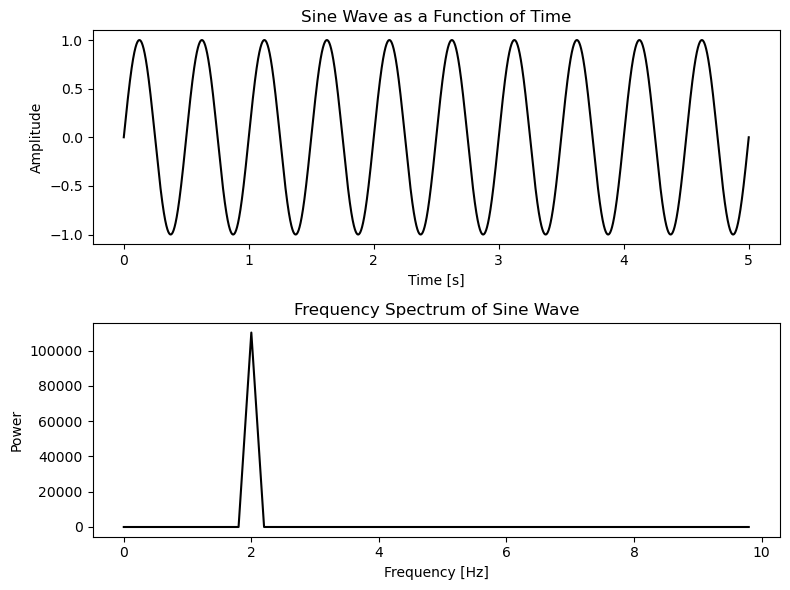

In [40]:
# 2 plots on same canvas; show only first 1000 elements of frequency spectrum
fig, axs = plt.subplots(2, 1, figsize=(8, 6))

axs[0].plot(x, y, 'k-')
axs[0].set_title('Sine Wave as a Function of Time')
axs[0].set_xlabel('Time [s]')
axs[0].set_ylabel('Amplitude')

# Plot the absolute value (magnitude) of the complex FFT output
# axs[1].plot(xft[:1000], np.abs(yft[:1000]), 'k-')
axs[1].plot(xft[:50], np.abs(yft[:50]), 'k-')
axs[1].set_title('Frequency Spectrum of Sine Wave')
axs[1].set_xlabel('Frequency [Hz]')
axs[1].set_ylabel('Power')

plt.tight_layout() # Prevents overlapping text between subplots
plt.show()


In [41]:
# Generate a sine wave of a given frequency and duration, sampled at some rate
def generate__noisy_sine_wave(freq, sample_rate, duration):
    x = np.linspace(0, duration, sample_rate * duration) # Samples
    frequencies = x * freq # Sampled frequencies
    y = np.sin((2 * np.pi) * frequencies)
    
    # Use NumPy's random module for array generation
    noise = np.random.random(size=len(x)) * np.random.normal(size=len(x))
    whitenoise = np.random.random(size=len(x))
    
    y += 0.1 * noise + 0.001 * whitenoise
    
    return x, y 

In [42]:
# Sine wave lasting 5 s; input sine wave frequency
f = float(input('Sine wave frequency [Hertz]:  '))
DURATION = int(input('Sine wave duration [whole number of seconds]:  '))
x, y = generate__noisy_sine_wave(f, SAMPLE_RATE, DURATION)

# Fourier analysis
N = SAMPLE_RATE * DURATION
xft = fftfreq(N, 1 / SAMPLE_RATE) # Middle of frequency bins
yft = fft(y) # Power of each sampled frequency

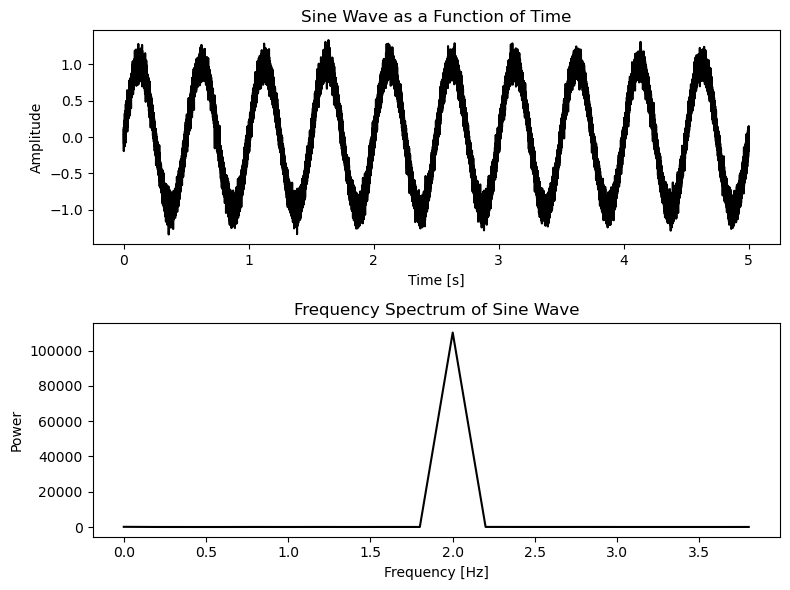

In [43]:
# 2 plots on same canvas; show signal frequency in center of plot
fig, axs = plt.subplots(2, 1, figsize=(8, 6)) # Use 'axs' so we don't overwrite 'plt'

axs[0].plot(x, y, 'k-')
axs[0].set_title('Sine Wave as a Function of Time')
axs[0].set_xlabel('Time [s]')
axs[0].set_ylabel('Amplitude')

# Use np.abs() to plot the magnitude of the complex FFT output
axs[1].plot(xft[:int(2*f*DURATION)], np.abs(yft[:int(2*f*DURATION)]), 'k-')
axs[1].set_title('Frequency Spectrum of Sine Wave')
axs[1].set_xlabel('Frequency [Hz]')
axs[1].set_ylabel('Power')

plt.tight_layout() # Added to prevent the labels from overlapping
plt.show()